<a href="https://colab.research.google.com/github/Sharif2138/African-Language-Health-QA-Challenge/blob/main/Exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 5: Prompt Engineering

## What Changes From Experiment 4

Instead of passing the raw question as input, we restructure the input
as an explicit instruction template:

    "You are a health expert. Answer the following question in Akan.
     Question: So amammerɛ anaa nyamesom mu...
     Answer:"

This is prompt engineering — explicitly telling the model:
1. What role it plays (health expert)
2. What language to respond in (full language name, not a code)
3. What the task structure is (Question / Answer format)

## Why This Might Help

In Experiment 4 the model received raw questions with no context about
what it was supposed to do with them. A seq2seq model fine-tuned this
way has to infer the task from the training signal alone.

By framing the input as an instruction, we leverage the fact that
mT5 was pretrained on multilingual web text that includes Q&A and
instruction-style content. The model has seen this kind of structure
before and can use it as a strong signal.

The explicit language instruction ("Answer in Akan") is particularly
important for low-resource languages where the model might otherwise
default to generating English.

## Hypothesis

Instruction-style prompts will produce more focused, language-consistent
answers and improve ROUGE scores over the raw-question baseline in Exp 4.

## Imports

In [ ]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

## Load Data and Apply Prompt Template

In [ ]:
train_small = pd.read_csv("/content/drive/MyDrive/datasets/train_small2.csv")
val_small   = pd.read_csv("/content/drive/MyDrive/datasets/val_small2.csv")
test        = pd.read_csv("/content/drive/MyDrive/datasets/test_clean.csv")

# Map subset codes to full language names
LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English"
}

def apply_prompt(df):
    df = df.copy()
    df["input"] = df.apply(
        lambda row: (
            f"You are a health expert. "
            f"Answer the following question in {LANGUAGE_MAP[row['subset']]}.\n"
            f"Question: {row['input']}\n"
            f"Answer:"
        ),
        axis=1
    )
    return df

train_small = apply_prompt(train_small)
val_small   = apply_prompt(val_small)
test        = apply_prompt(test)

train_ds = Dataset.from_pandas(train_small)
val_ds   = Dataset.from_pandas(val_small)
test_ds  = Dataset.from_pandas(test)

print("train_ds:", len(train_ds))
print("val_ds  :", len(val_ds))
print("test_ds :", len(test_ds))
print()
print("Sample prompt:")
print(train_small["input"].iloc[0])

train_ds: 4000
val_ds  : 1200
test_ds : 2618

Sample prompt:
You are a health expert. Answer the following question in Akan.
Question: Mɛyɛ dɛn ahu sɛ nna ne abusuabɔ ho nsɛm a ɛwɔ Intanɛt so no yɛ nokware, na wotumi de ho to so?
Answer:


## Tokenizer and Tokenization

MAX_INPUT_LENGTH is increased to 128 to accommodate the instruction
prefix which adds roughly 20-25 tokens to every input.

In [ ]:
MODEL_NAME        = "google/mt5-small"
MAX_INPUT_LENGTH  = 128
MAX_TARGET_LENGTH = 192

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("pad_token_id:", tokenizer.pad_token_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pad_token_id: 0


In [ ]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val   = val_ds.map(tokenize,       batched=True, remove_columns=val_ds.column_names)
tok_test  = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)
print()

# Verify prompt tokens fit within MAX_INPUT_LENGTH
sample_len = len(tok_train[0]["input_ids"])
print(f"Sample input length: {sample_len} tokens")

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})

Sample input length: 66 tokens


## Model and LoRA

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

model.config.decoder_start_token_id = tokenizer.pad_token_id
model.config.forced_bos_token_id    = None

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 172,032 || all params: 300,348,800 || trainable%: 0.0573


## Data Collator

In [ ]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

## Evaluation Metric

In [ ]:
rouge = evaluate.load("rouge")

def clean(text):
    return re.sub(r"<extra_id_\d+>", "", text).strip()

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = [clean(t) for t in
                      tokenizer.batch_decode(preds,  skip_special_tokens=True)]
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

## Training

In [ ]:
args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/checkpoints/exp5",

    num_train_epochs=3,
    learning_rate=3e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=192,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=1,
    dataloader_num_workers=0,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

{'loss': '50.23', 'grad_norm': '992.4', 'learning_rate': '0.0002904', 'epoch': '0.1'}
{'loss': '45.12', 'grad_norm': '483.2', 'learning_rate': '0.0002804', 'epoch': '0.2'}
{'loss': '37.38', 'grad_norm': '658.3', 'learning_rate': '0.0002704', 'epoch': '0.3'}
{'loss': '29.67', 'grad_norm': '144.8', 'learning_rate': '0.0002604', 'epoch': '0.4'}
{'loss': '23.3', 'grad_norm': '100.3', 'learning_rate': '0.0002504', 'epoch': '0.5'}
{'loss': '20.29', 'grad_norm': '55.06', 'learning_rate': '0.0002404', 'epoch': '0.6'}
{'loss': '17.57', 'grad_norm': '19.8', 'learning_rate': '0.0002304', 'epoch': '0.7'}
{'loss': '15.82', 'grad_norm': '15.55', 'learning_rate': '0.0002204', 'epoch': '0.8'}
{'loss': '14.63', 'grad_norm': '6.32', 'learning_rate': '0.0002104', 'epoch': '0.9'}
{'loss': '13.85', 'grad_norm': '3.193', 'learning_rate': '0.0002004', 'epoch': '1'}
{'eval_loss': '4.856', 'eval_ROUGE1': '0.0426', 'eval_ROUGEL': '0.0392', 'eval_runtime': '654.2', 'eval_samples_per_second': '1.834', 'eval_steps

TrainOutput(global_step=750, training_loss=16.701745157877603, metrics={'train_runtime': 2577.8753, 'train_samples_per_second': 4.655, 'train_steps_per_second': 0.291, 'train_loss': 16.701745157877603, 'epoch': 3.0})

## Save Best Model

In [ ]:
trainer.save_model("/content/drive/MyDrive/models/exp5/best_model")
tokenizer.save_pretrained("/content/drive/MyDrive/models/exp5/best_model")
print("Model saved")

Model saved


## Validation Predictions and Inspection

In [ ]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

val_loader = DataLoader(
    tok_val,
    batch_size=8,
    collate_fn=DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        padding=True,
        pad_to_multiple_of=8
    )
)

pred_text = []
ref_text  = []

for batch in val_loader:
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels         = batch["labels"]

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=192,
            num_beams=1,
            decoder_start_token_id=tokenizer.pad_token_id,
            forced_bos_token_id=None,
            no_repeat_ngram_size=3
        )

    pred_text.extend([
        clean(t) for t in
        tokenizer.batch_decode(outputs, skip_special_tokens=True)
    ])

    labels = torch.where(labels != -100, labels, tokenizer.pad_token_id)
    ref_text.extend(
        tokenizer.batch_decode(labels, skip_special_tokens=True)
    )

print(f"Generated {len(pred_text)} predictions")

Generated 1200 predictions


In [ ]:
scores = rouge.compute(
    predictions=pred_text,
    references=ref_text,
    use_stemmer=True
)
print("ROUGE-1:", round(scores["rouge1"], 4))
print("ROUGE-L:", round(scores["rougeL"], 4))

ROUGE-1: 0.142
ROUGE-L: 0.1052


In [ ]:
eng_indices = val_small[val_small["subset"].str.startswith("Eng")].index[:3].tolist()
aka_indices = val_small[val_small["subset"] == "Aka_Gha"].index[:2].tolist()

for i in aka_indices + eng_indices:
    print("="*70)
    print("LANGUAGE :", val_small.iloc[i]["subset"])
    print("QUESTION :", val_small.iloc[i]["input"][:150])
    print("REFERENCE:", ref_text[i][:200])
    print("GENERATED:", pred_text[i][:200])
    print()

LANGUAGE : Aka_Gha
QUESTION : You are a health expert. Answer the following question in Akan.
Question: So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea a
REFERENCE: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso kɛse. Amammerɛ anaa ɔsom ahorow bi betumi asi ahobr
GENERATED: nsɛm ho nnsɛnea nsusuwii a a wɔn a, nsuwii nɔ a. A nɛ nkɔ nyɛ nmɛ aa sɛɛ sɛnɛ e n’ n' n ntumi nsoro nsamɛ bɛ nsoma nsi nkwɛ ɛm nna nsan nkɛm mu nwumɛ o nwɔ nnam ntana nwu nbɛ ayɛ abɛ sɔm a mu a naa ea

LANGUAGE : Aka_Gha
QUESTION : You are a health expert. Answer the following question in Akan.
Question: Dwuma bɛn na ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun 
REFERENCE: Ahyehyɛde ahorow a egyina mpɔtamu hɔ, nhyehyɛe ahorow a mmabun di anim, ne atipɛnfo nkitahodi di dwuma titiriw wɔ mmabun nna ne awoɔ apomoden a wɔboa wɔ wiase nyinaa apomoden ho tebea horow a egye ntɛ
G

## Learning Curves

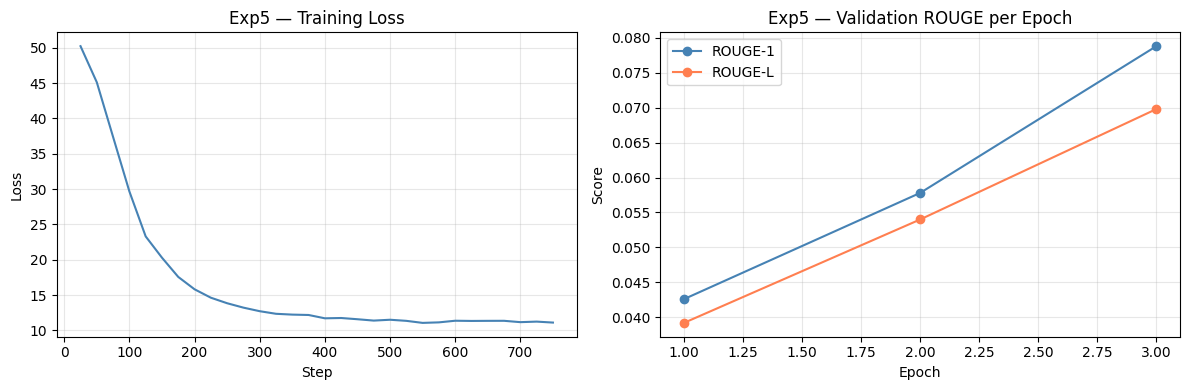

Plot saved


In [ ]:
history    = pd.DataFrame(trainer.state.log_history)
train_logs = history.dropna(subset=["loss"])
eval_logs  = history.dropna(subset=["eval_ROUGE1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Exp5 — Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGE1"],
             marker="o", label="ROUGE-1", color="steelblue")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGEL"],
             marker="o", label="ROUGE-L", color="coral")
axes[1].set_title("Exp5 — Validation ROUGE per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/plots/exp5_curves.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Plot saved")